In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load all 3 datasets
df_diabetes = pd.read_csv('../data/diabetes_clean.csv')
df_diabetes2 = pd.read_csv('../data/diabetes_dataset_clean.csv')
df_heart = pd.read_csv('../data/heart_clean.csv')

print("Diabetes (Old) Shape:", df_diabetes.shape)
print("Diabetes (New) Shape:", df_diabetes2.shape)
print("Heart Disease Shape:", df_heart.shape)

Diabetes (Old) Shape: (768, 9)
Diabetes (New) Shape: (70000, 34)
Heart Disease Shape: (920, 23)


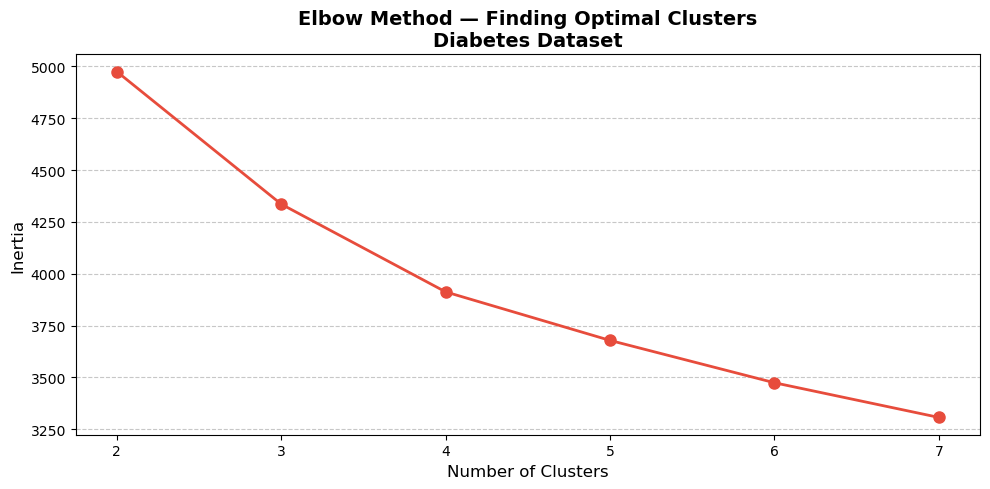

In [3]:
# Scale the data
scaler = StandardScaler()
X_diabetes = df_diabetes.drop('Outcome', axis=1)
X_diabetes_scaled = scaler.fit_transform(X_diabetes)

# Find optimal clusters
inertias = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_diabetes_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, marker='o', linewidth=2,
         color='#E74C3C', markersize=8)
plt.title('Elbow Method — Finding Optimal Clusters\nDiabetes Dataset',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('../plots/diabetes_kmeans_elbow.png', dpi=150)
plt.show()

In [4]:
# Apply KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_diabetes['Cluster'] = kmeans.fit_predict(X_diabetes_scaled)

# Analyze each cluster
cluster_analysis = df_diabetes.groupby('Cluster').agg({
    'Glucose': 'mean',
    'BMI': 'mean',
    'Age': 'mean',
    'Insulin': 'mean',
    'Outcome': 'mean'
}).round(2)

cluster_analysis['Diabetes Rate'] = (cluster_analysis['Outcome'] * 100).round(1)
cluster_analysis['Patient Count'] = df_diabetes.groupby('Cluster').size()

print("Cluster Analysis:")
print(cluster_analysis.to_string())

Cluster Analysis:
         Glucose    BMI    Age  Insulin  Outcome  Diabetes Rate  Patient Count
Cluster                                                                       
0         130.79  32.81  46.04   139.63     0.52           52.0            248
1         106.62  28.50  25.94   113.33     0.13           13.0            335
2         136.64  39.15  29.30   191.57     0.52           52.0            185


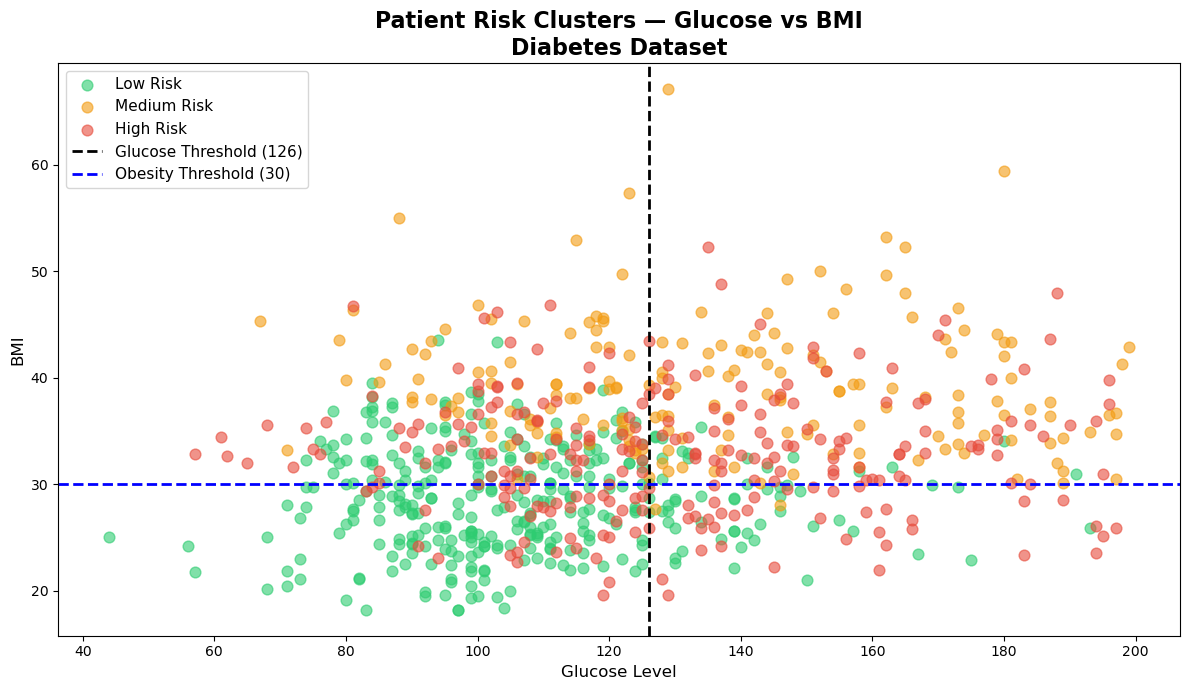

In [6]:
# Rename clusters
cluster_names = {0: 'High Risk', 1: 'Low Risk', 2: 'Medium Risk'}
df_diabetes['Cluster Name'] = df_diabetes['Cluster'].map(cluster_names)

plt.figure(figsize=(12, 7))
colors = {'Low Risk': '#2ECC71', 'Medium Risk': '#F39C12', 'High Risk': '#E74C3C'}

for cluster, color in colors.items():
    mask = df_diabetes['Cluster Name'] == cluster
    plt.scatter(df_diabetes[mask]['Glucose'],
                df_diabetes[mask]['BMI'],
                c=color, label=cluster,
                alpha=0.6, s=60)

plt.axvline(126, color='black', linestyle='--', linewidth=2, label='Glucose Threshold (126)')
plt.axhline(30, color='blue', linestyle='--', linewidth=2, label='Obesity Threshold (30)')

plt.title('Patient Risk Clusters — Glucose vs BMI\nDiabetes Dataset',
          fontsize=16, fontweight='bold')
plt.xlabel('Glucose Level', fontsize=12)
plt.ylabel('BMI', fontsize=12)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../plots/diabetes_clusters.png', dpi=150)
plt.show()

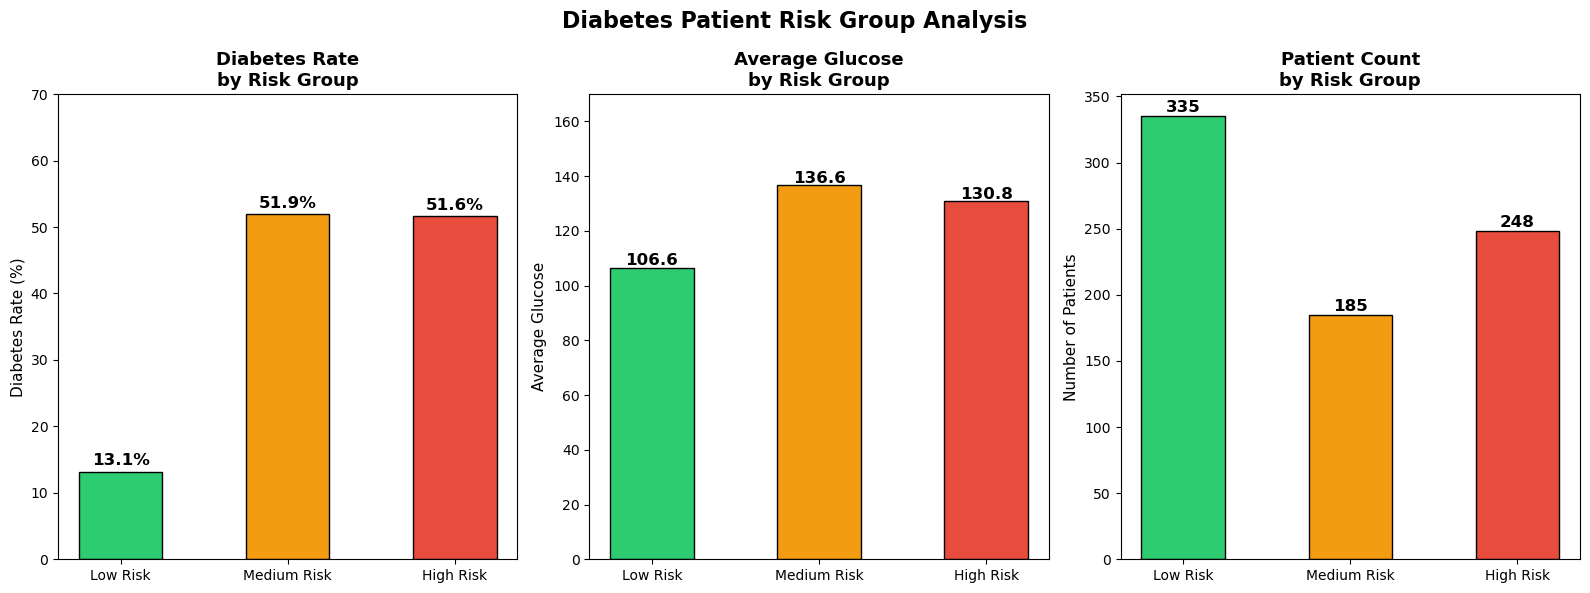

In [7]:
# Cluster summary bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

cluster_names = {0: 'High Risk', 1: 'Low Risk', 2: 'Medium Risk'}
df_diabetes['Cluster Name'] = df_diabetes['Cluster'].map(cluster_names)
colors = ['#2ECC71', '#F39C12', '#E74C3C']
clusters = ['Low Risk', 'Medium Risk', 'High Risk']

# Plot 1 — Diabetes Rate
diabetes_rate = df_diabetes.groupby('Cluster Name')['Outcome'].mean() * 100
diabetes_rate = diabetes_rate.reindex(clusters)
bars1 = axes[0].bar(clusters, diabetes_rate.values,
                    color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars1, diabetes_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.1f}%', ha='center',
                 fontsize=12, fontweight='bold')
axes[0].set_title('Diabetes Rate\nby Risk Group', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Diabetes Rate (%)', fontsize=11)
axes[0].set_ylim(0, 70)

# Plot 2 — Average Glucose
glucose_mean = df_diabetes.groupby('Cluster Name')['Glucose'].mean()
glucose_mean = glucose_mean.reindex(clusters)
bars2 = axes[1].bar(clusters, glucose_mean.values,
                    color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars2, glucose_mean.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.1f}', ha='center',
                 fontsize=12, fontweight='bold')
axes[1].set_title('Average Glucose\nby Risk Group', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Glucose', fontsize=11)
axes[1].set_ylim(0, 170)

# Plot 3 — Patient Count
patient_count = df_diabetes.groupby('Cluster Name').size()
patient_count = patient_count.reindex(clusters)
bars3 = axes[2].bar(clusters, patient_count.values,
                    color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars3, patient_count.values):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3,
                 f'{val}', ha='center',
                 fontsize=12, fontweight='bold')
axes[2].set_title('Patient Count\nby Risk Group', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Number of Patients', fontsize=11)

plt.suptitle('Diabetes Patient Risk Group Analysis',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/diabetes_cluster_analysis.png', dpi=150)
plt.show()

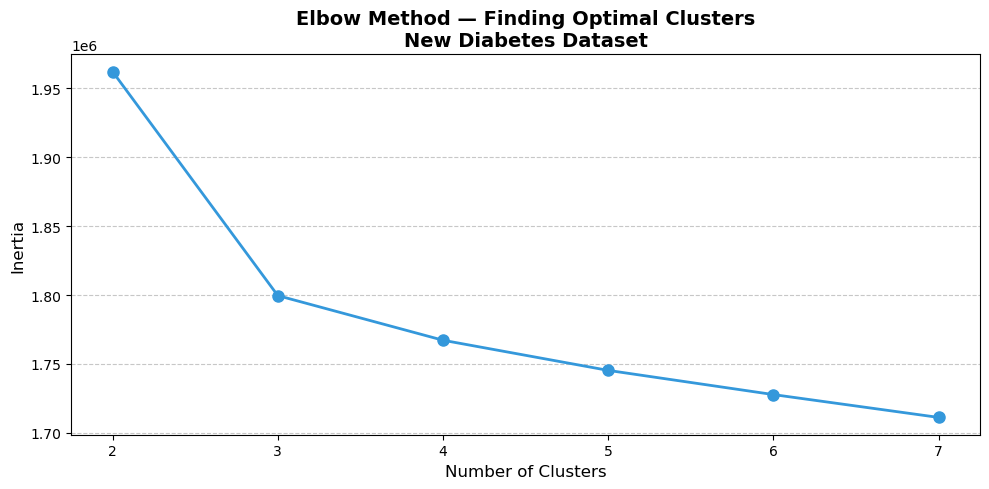

In [8]:
# Scale the data
X_diabetes2 = df_diabetes2.drop('Target', axis=1)
scaler2 = StandardScaler()
X_diabetes2_scaled = scaler2.fit_transform(X_diabetes2)

# Find optimal clusters
inertias2 = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_diabetes2_scaled)
    inertias2.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias2, marker='o', linewidth=2,
         color='#3498DB', markersize=8)
plt.title('Elbow Method — Finding Optimal Clusters\nNew Diabetes Dataset',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('../plots/diabetes2_kmeans_elbow.png', dpi=150)
plt.show()

In [9]:
kmeans2 = KMeans(n_clusters=4, random_state=42, n_init=10)
df_diabetes2['Cluster'] = kmeans2.fit_predict(X_diabetes2_scaled)

# Analyze each cluster
cluster_analysis2 = df_diabetes2.groupby('Cluster').agg({
    'Blood Glucose Levels': 'mean',
    'BMI': 'mean',
    'Age': 'mean',
    'Insulin Levels': 'mean',
    'Target': lambda x: x.value_counts().index[0]
}).round(2)

cluster_analysis2['Patient Count'] = df_diabetes2.groupby('Cluster').size()

type_labels = {0: 'Prediabetic', 1: 'Type 1', 2: 'Type 2', 3: 'Type 3'}
cluster_analysis2['Dominant Type'] = cluster_analysis2['Target'].map(type_labels)

print("Cluster Analysis:")
print(cluster_analysis2.to_string())

Cluster Analysis:
         Blood Glucose Levels    BMI    Age  Insulin Levels  Target  Patient Count Dominant Type
Cluster                                                                                         
0                      121.63  24.79  29.72           19.75       1          16355        Type 1
1                      121.88  24.81  29.78           19.93       1          16125        Type 1
2                      202.51  18.16   6.62           12.01       1          16133        Type 1
3                      188.31  29.76  54.63           31.54       2          21387        Type 2


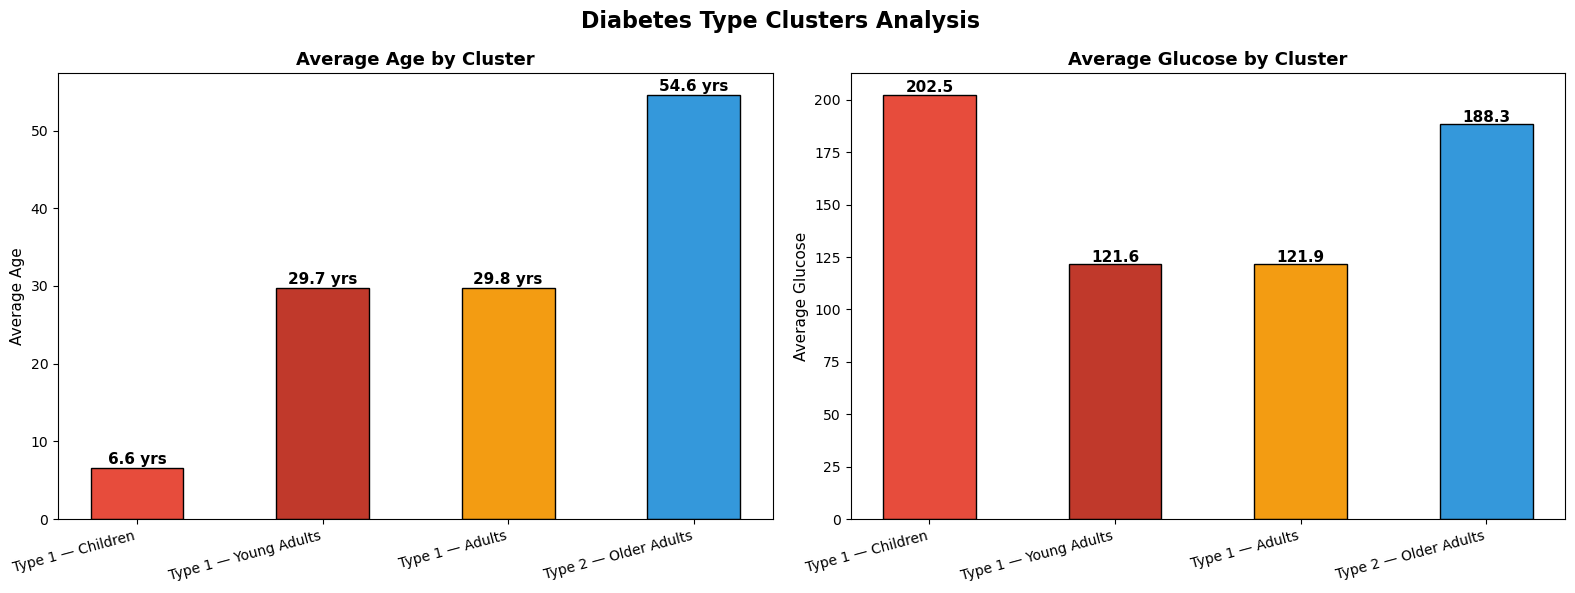

In [10]:
cluster_names2 = {
    0: 'Type 1 — Young Adults',
    1: 'Type 1 — Adults',
    2: 'Type 1 — Children',
    3: 'Type 2 — Older Adults'
}

df_diabetes2['Cluster Name'] = df_diabetes2['Cluster'].map(cluster_names2)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#E74C3C', '#C0392B', '#F39C12', '#3498DB']
cluster_order = ['Type 1 — Children', 'Type 1 — Young Adults', 
                 'Type 1 — Adults', 'Type 2 — Older Adults']

# Plot 1 — Average Age
age_means = df_diabetes2.groupby('Cluster Name')['Age'].mean()
age_means = age_means.reindex(cluster_order)
bars1 = axes[0].bar(cluster_order, age_means.values,
                    color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars1, age_means.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f} yrs', ha='center',
                 fontsize=11, fontweight='bold')
axes[0].set_title('Average Age by Cluster', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Age', fontsize=11)
axes[0].set_xticklabels(cluster_order, rotation=15, ha='right')

# Plot 2 — Average Glucose
glucose_means = df_diabetes2.groupby('Cluster Name')['Blood Glucose Levels'].mean()
glucose_means = glucose_means.reindex(cluster_order)
bars2 = axes[1].bar(cluster_order, glucose_means.values,
                    color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars2, glucose_means.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.1f}', ha='center',
                 fontsize=11, fontweight='bold')
axes[1].set_title('Average Glucose by Cluster', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Glucose', fontsize=11)
axes[1].set_xticklabels(cluster_order, rotation=15, ha='right')

plt.suptitle('Diabetes Type Clusters Analysis',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/diabetes2_clusters.png', dpi=150)
plt.show()